# Incomplete Cholesky factorization as a preconditioner
Elisa Klunder (s5190940) and Dries Wedda (s4745329), 12.12.2025

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.sparse import diags

In [4]:
# source: https://stackoverflow.com/questions/5842903/block-tridiagonal-matrix-python for scipy.sparse.diags
# source: https://thauwa.me/2021/12/03/how-to-create-a-block-tridiagonal-matrix-using-numpy-in-python-ft-personal-trauma-variables/
# for numpy.kron
def make_stieltjes(m: int) -> np.ndarray:
    """Create Stieltjes matrix resulting from discretization of the Poisson equation in two dimensions.

    This is an `m^2` by `m^2` block tridiagonal matrix. It has `D` on main diagonal, and `-I` off-diagonal.
    `D` is again an `m` by `m` tridiagonal matrix, with 4 on main diagonal, and -1 off-diagonal.

    TODO reimplement this
    """
    D = diags(diagonals=[4, -1, -1], offsets=[0, 1, -1], shape=(m, m), dtype=int).toarray()       # create D blocks
    I = np.eye(m, dtype=int)                                                                      # for -I blocks

    I_above = np.eye(m, k=1, dtype=int)     # identity shifted one above
    I_below = np.eye(m, k=-1, dtype=int)    # identity shifted one below

    return (
        np.kron(I_above, -I)                # -I above diagonal
        + np.kron(I, D)                     # D on diagonal
        + np.kron(I_below, -I)              # -I below diagonal
    )

In [2]:
def compute_Z(A: np.ndarray) -> np.ndarray:
    """Assumes A is symmetric which is a reasonable assumption, since it should be PSD."""
    return (A != 0).astype(int)


def ichol_helper(A: np.ndarray, Z: np.ndarray, n: int) -> np.ndarray:
    """Recursive helper function that implements the algorithm."""
    if n == 1:
        return np.sqrt(A)

    alpha = A[0,0]
    v = A[1:n, 0]
    B = A[1:n, 1:n]
    w = v / np.sqrt(alpha) * Z[1:n, 0]
    A_1 = (B - np.outer(w, w.T)) * Z[1:n, 1:n]
    H_1 = ichol_helper(A_1, Z[1:n, 1:n], n - 1)

    return np.block([
        [np.sqrt(alpha), np.zeros(shape=(n - 1, ))],
        [np.atleast_2d(w).T, H_1]],
    )


def ichol(A: np.ndarray) -> np.ndarray:
    """Wrap implementation so the user has to supply fewer arguments."""
    Z = compute_Z(A)
    return ichol_helper(A, Z, n=A.shape[0])

In [ ]:
# https://stackoverflow.com/questions/64056586/how-can-i-count-number-of-iterations-that-ran-for-sparse-linear-solver-in-scipy
def run_experiment(A: np.ndarray, b: np.ndarray, key_suffix: str) -> dict:
    """Run experiment for CG or PCG."""
    iters = 0
    def callback(_) -> None:
        nonlocal iters
        iters += 1

    if key_suffix == "pre":
        L = ichol(A)
        cond_num = np.linalg.cond(L @ L.T)
        L = scipy.sparse.csr_matrix(L)

        def apply_preconditioner(x):
            """Inner function to access L directly."""
            veccy = scipy.sparse.linalg.spsolve_triangular(L, x, lower=True)
            return scipy.sparse.linalg.spsolve_triangular(L.T, veccy, lower=False)

        diag_precon = scipy.sparse.linalg.LinearOperator(A.shape, apply_preconditioner)
        result = scipy.sparse.linalg.cg(A, b, M=diag_precon, callback=callback)[0]
    else:
        result = scipy.sparse.linalg.cg(A, b, callback=callback)[0]  # ignoring result
        cond_num = np.linalg.cond(A)

    return {
        f"iters_{key_suffix}": iters,
        f"cond_{key_suffix}": cond_num,
    }

max_m = 20
results = []

for m in range(1, max_m + 1):
    A = make_stieltjes(m)
    b = np.random.random((m * m, ))                 # random goal with b_i ~ N(0,1)

    it_results = {"matrix_size": m}
    for key_suffix in ("pre", "vanilla"):
        it_results.update(run_experiment(A, b, key_suffix))

    results.append(it_results)

results_df = pd.DataFrame(results)

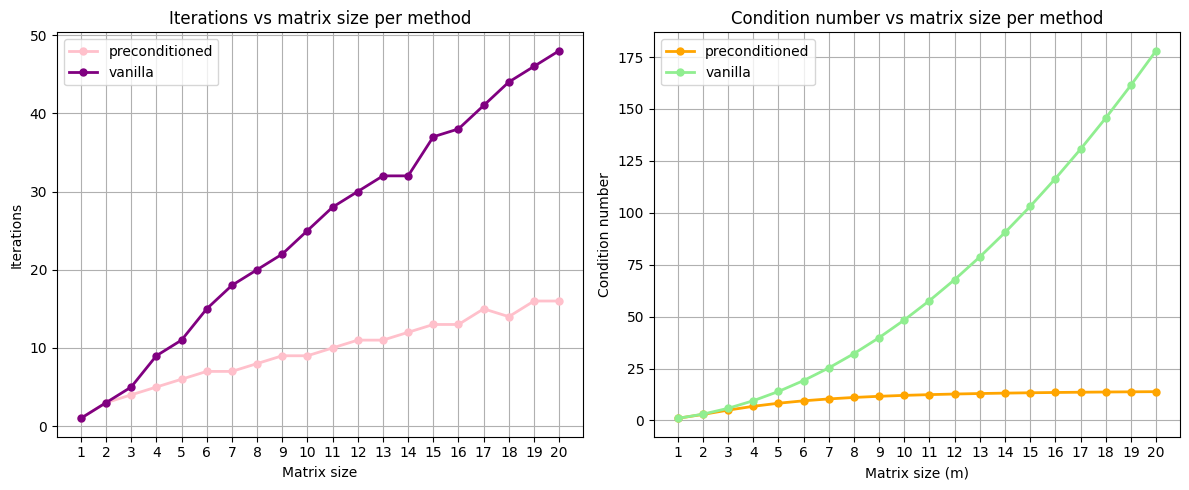

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

results_df.plot(x="matrix_size", y=["iters_pre", "iters_vanilla"], ax=ax1, marker="o",
        color=["pink", "purple"], linewidth=2, markersize=5)
ax1.set_xlabel("Matrix size")
ax1.set_ylabel("Iterations")
ax1.set_title("Iterations vs matrix size per method")
ax1.set_xticks(results_df["matrix_size"])
ax1.legend(["preconditioned", "vanilla"])
ax1.grid()

results_df.plot(x="matrix_size", y=["cond_pre", "cond_vanilla"], ax=ax2, marker="o",
        color=["orange", "lightgreen"], linewidth=2, markersize=5)
ax2.set_xlabel("Matrix size (m)")
ax2.set_ylabel("Condition number")
ax2.set_title("Condition number vs matrix size per method")
ax2.set_xticks(results_df["matrix_size"])
ax2.legend(["preconditioned", "vanilla"])
ax2.grid()

plt.tight_layout()
plt.show()